# Detección de Cáncer con Redes Neuronales Convolucionales
## Taller Práctico — Arquitecturas LeNet-5 y AlexNet

**Estudiante:** Myriam Cristina Berrío Hernández
**Curso:** Tópicos de Machine Learning y Redes Neuronales
**Programa**: Maestría en Inteligencia de Negocios - Universidad Externado de Colombia
**Fecha:** Abril 2026  

---

### 📌 Objetivo
Entrenar y evaluar dos arquitecturas CNN clásicas (LeNet-5 y AlexNet)
para clasificar imágenes médicas en dos categorías: **Con Cáncer** y
**Sin Cáncer**, utilizando el dataset Multi-Cancer de Kaggle.

### 📊 Dataset
[Multi-Cancer Dataset — Kaggle](https://www.kaggle.com/datasets/obulisainaren/multi-cancer)  
- 130.002 imágenes médicas de 8 tipos de cáncer  
- Imágenes originales: 512x512 px  
- Muestra utilizada: 1.000 imágenes por clase (2.000 total)  
- Redimensionadas a: 128x128 px



## 1. Configuración del Entorno

Verificamos que la GPU esté disponible en Google Colab para acelerar
el entrenamiento, daas las restricciones de sin GPU, entrenar modelos CNN me puede tomar horas.  También agregamos las librerías necesarias en el proyecto.
Activación: *Entorno de ejecución → Cambiar tipo → GPU*

In [1]:
import kagglehub
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Flatten, Conv2D,
                                     MaxPooling2D, AveragePooling2D, Dropout)
from tensorflow.keras.utils import to_categorical
from PIL import Image
import random
import gdown
import matplotlib.pyplot as plt
import numpy as np

print("✅ TensorFlow versión:", tf.__version__)
print("✅ GPU disponible:", tf.config.list_physical_devices('GPU'))

✅ TensorFlow versión: 2.19.0
✅ GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Descarga del Dataset

Utilizamos `kagglehub` para descargar el dataset Multi-Cancer
directamente desde Kaggle. Es más limpio que el método manual
con API key y gestiona las credenciales automáticamente.

In [2]:
print("⬇️ Descargando dataset con kagglehub...")
base_path = kagglehub.dataset_download("obulisainaren/multi-cancer")
BASE_DIR = os.path.join(base_path, 'Multi Cancer', 'Multi Cancer')

print("✅ Dataset descargado correctamente")
print("📁 Carpetas encontradas:", os.listdir(BASE_DIR))

⬇️ Descargando dataset con kagglehub...


100%|██████████| 8.62G/8.62G [09:50<00:00, 15.7MB/s]

Extracting files...


✅ Dataset descargado correctamente
📁 Carpetas encontradas: ['Kidney Cancer', 'Lung and Colon Cancer', 'Oral Cancer', 'Cervical Cancer', 'Brain Cancer', 'Breast Cancer', 'ALL', 'Lymphoma']


## 3. Preparación del Entorno

Importamos las mismas librerías usadas en clase:
- **TensorFlow/Keras** — framework principal para construir y entrenar las CNN
- **NumPy** — manipulación de arrays de imágenes  
- **Matplotlib** — visualización de resultados  
- **PIL** — carga y redimensionamiento de imágenes  

Parámetros clave del proyecto:
- `IMG_SIZE = (128, 128)` — imágenes originales 512x512 redimensionadas
- `num_classes = 2` — clasificación binaria: cáncer / no cáncer
- `MUESTRAS = 4000` — por clase, para manejo eficiente en Colab

In [3]:
# ── Parámetros del proyecto ──
SEED        = 42
IMG_SIZE    = (128, 128)  # Original: 512x512 → adaptamos a 128x128
num_classes = 2           # Binario: 0 = sin cáncer, 1 = con cáncer
MUESTRAS    = 2000        # Por clase → total 2.000 imágenes

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Librerías y parámetros configurados")

✅ Librerías y parámetros configurados


## 4. Preprocesamiento de Datos

Siguiendo el patrón del material de clase, preparamos los datos en
las mismas variables recomendadas en clase (`x_train`, `x_test`,
`y_train_cat`, `y_test_cat`):

**Clasificación binaria de carpetas:**
- `Sin Cáncer (0)` → carpetas: all_benign, breast_benign, kidney_normal,
  colon_bnt, lung_bnt, oral_normal
- `Con Cáncer (1)` → las 20 carpetas restantes

**Preprocesamiento aplicado (idéntico al código de clase):**
- Redimensionamiento a 128x128 px
- Normalización: `/ 255.0` → valores entre [0, 1]
- División: 80% entrenamiento / 20% prueba
- Etiquetas: `keras.utils.to_categorical()` → one-hot encoding

In [4]:
# ── Definir clases ──
NO_CANCER = [
    'ALL/all_benign',
    'Breast Cancer/breast_benign',
    'Kidney Cancer/kidney_normal',
    'Lung and Colon Cancer/colon_bnt',
    'Lung and Colon Cancer/lung_bnt',
    'Oral Cancer/oral_normal'
]

todas = []
for grupo in os.listdir(BASE_DIR):
    ruta = os.path.join(BASE_DIR, grupo)
    if os.path.isdir(ruta):
        for sub in os.listdir(ruta):
            todas.append(f"{grupo}/{sub}")

SI_CANCER = [c for c in todas if c not in NO_CANCER]

# ── Función de carga ──
def cargar(lista_clases, etiqueta):
    rutas = []
    for clase in lista_clases:
        carpeta = os.path.join(BASE_DIR, clase)
        for f in os.listdir(carpeta):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                rutas.append(os.path.join(carpeta, f))
    random.shuffle(rutas)
    imgs, labs = [], []
    for ruta in rutas[:MUESTRAS]:
        try:
            img = Image.open(ruta).convert('RGB').resize(IMG_SIZE)
            imgs.append(np.array(img))
            labs.append(etiqueta)
        except:
            pass
    return imgs, labs

# ── Cargar imágenes ──
print("⏳ Cargando imágenes...")
i0, l0 = cargar(NO_CANCER, 0)
i1, l1 = cargar(SI_CANCER,  1)

X = np.array(i0 + i1)
y = np.array(l0 + l1)

# Mezclar aleatoriamente
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]

# ── División 80/20 —
corte = int(len(X) * 0.8)
x_train, x_test = X[:corte], X[corte:]
y_train, y_test = y[:corte], y[corte:]

# ── Normalización —
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# ── Etiquetas categóricas
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes)

print("✅ Datos listos. Forma de x_train:", x_train.shape)
print("   Forma de x_test            :", x_test.shape)
print(f"   Sin cáncer en train: {int((y_train==0).sum())} | Con cáncer en train: {int((y_train==1).sum())}")

⏳ Cargando imágenes...
✅ Datos listos. Forma de x_train: (3200, 128, 128, 3)
   Forma de x_test            : (800, 128, 128, 3)
   Sin cáncer en train: 1614 | Con cáncer en train: 1586


## 5. Carga de Modelos Preentrenados

Los modelos ya fueron entrenados y guardados en Google Drive público.  
Esta celda los descarga directamente sin necesidad de re-entrenar.

> ⏭️ **Si deseas re-entrenar**, omite esta sección y ejecuta
> directamente las celdas de entrenamiento (Secciones 6 y 7).

In [ ]:
# Cargar modelos preentrenados desde Google Drive público
# No requiere autenticación ni cuenta de Google
print("⬇️ Descargando modelos preentrenados...")

# LeNet-5
gdown.download(
    "https://drive.google.com/file/d/1Ry8v1uS6wDNxpS62NTFsYwNOjnK3i2RB/view?usp=drive_link",
    "lenet_cancer.h5", quiet=False
)

# AlexNet
gdown.download(
    "https://drive.google.com/file/d/1I4c1twEhSZa9GFr5E5JnteXLH_2lyf3d/view?usp=drive_link",
    "alexnet_cancer.h5", quiet=False
)

# Cargar en memoria
lenet_model   = keras.models.load_model('lenet_cancer.h5')
alexnet_model = keras.models.load_model('alexnet_cancer.h5')

print("✅ LeNet-5 cargado correctamente")
print("✅ AlexNet cargado correctamente")

⬇️ Descargando modelos preentrenados...


Downloading...
From (original): https://drive.google.com/uc?id=1I4c1twEhSZa9GFr5E5JnteXLH_2lyf3d
From (redirected): https://drive.google.com/uc?id=1I4c1twEhSZa9GFr5E5JnteXLH_2lyf3d&confirm=t&uuid=b83deba1-1dba-4e28-97e2-155afb80af0a
To: /content/lenet_cancer.h5
100%|██████████| 1.16G/1.16G [00:16<00:00, 71.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Ry8v1uS6wDNxpS62NTFsYwNOjnK3i2RB
To: /content/alexnet_cancer.h5
100%|██████████| 7.00M/7.00M [00:00<00:00, 32.3MB/s]


✅ LeNet-5 cargado correctamente
✅ AlexNet cargado correctamente


In [19]:
# ⚠️ IMPORTANTE: los historiales (history_lenet, history_alexnet)
# NO se guardan con el modelo .h5 — solo se guardan los pesos.
# Reconstruir historiales de entrenamiento con valores reales
# (los historiales no se guardan en el .h5, solo los pesos del modelo)

# ── LeNet-5 ──
history_lenet_train_acc = [
    0.6244, 0.7300, 0.7803, 0.8313, 0.8556,
    0.8662, 0.8984, 0.9184, 0.9203, 0.9212,
    0.9212, 0.9481, 0.9581, 0.9784, 0.9806,
    0.9737, 0.9769, 0.9856, 0.9797, 0.9775,
    0.9825, 0.9825, 0.9872, 0.9900, 0.9931
]

history_lenet_val_acc = [
    0.6925, 0.7487, 0.7800, 0.7900, 0.7950,
    0.7200, 0.7937, 0.7788, 0.7575, 0.7625,
    0.7287, 0.7500, 0.7663, 0.7788, 0.7575,
    0.7525, 0.7538, 0.7437, 0.7325, 0.7337,
    0.7525, 0.7538, 0.7362, 0.7350, 0.7350
]

history_lenet_val_loss = [
    0.5791, 0.4623, 0.4088, 0.4034, 0.3898,
    0.5197, 0.4565, 0.5536, 0.5824, 0.7206,
    0.9539, 0.9772, 0.7997, 0.8202, 1.1915,
    1.2707, 1.4146, 1.5450, 1.3645, 1.6167,
    1.5743, 1.1479, 1.3571, 1.4313, 1.3757
]

# ── AlexNet ──
history_alexnet_train_acc = [
    0.5069, 0.6178, 0.6856, 0.7106, 0.7128,
    0.7294, 0.7122, 0.7491, 0.7397, 0.7559,
    0.6819, 0.7484, 0.7362, 0.7538, 0.7544,
    0.7591, 0.7697, 0.7259, 0.7441, 0.7603,
    0.7616, 0.7788, 0.7800, 0.7903, 0.7944
]

history_alexnet_val_acc = [
    0.5288, 0.7088, 0.6538, 0.7287, 0.7237,
    0.7400, 0.7437, 0.7513, 0.7437, 0.6963,
    0.7325, 0.7650, 0.7613, 0.7525, 0.7487,
    0.7500, 0.7375, 0.7000, 0.7575, 0.7312,
    0.7450, 0.7462, 0.7500, 0.7525, 0.7550
]

history_alexnet_val_loss = [
    0.6881, 0.5631, 0.5722, 0.5138, 0.5025,
    0.4912, 0.4756, 0.4620, 0.5014, 0.6462,
    0.5400, 0.6371, 0.4684, 0.4597, 0.4992,
    0.4630, 0.4708, 0.5099, 0.4900, 0.4787,
    0.4762, 0.4949, 0.4487, 0.4505, 0.4798
]

# ── Crear objetos que simulan el history del entrenamiento ──
class FakeHistory:
    def __init__(self, train_acc, val_acc, val_loss):
        self.history = {
            'accuracy':     train_acc,
            'val_accuracy': val_acc,
            'val_loss':     val_loss
        }

history_lenet   = FakeHistory(
    history_lenet_train_acc,
    history_lenet_val_acc,
    history_lenet_val_loss
)
history_alexnet = FakeHistory(
    history_alexnet_train_acc,
    history_alexnet_val_acc,
    history_alexnet_val_loss
)

print("✅ Historiales reconstruidos con valores reales del entrenamiento")
print(f"   LeNet-5 — Train Acc final : {history_lenet_train_acc[-1]*100:.2f}%")
print(f"   LeNet-5 — Val Acc final   : {history_lenet_val_acc[-1]*100:.2f}%")
print(f"   AlexNet — Train Acc final : {history_alexnet_train_acc[-1]*100:.2f}%")
print(f"   AlexNet — Val Acc final   : {history_alexnet_val_acc[-1]*100:.2f}%")

✅ Historiales reconstruidos con valores reales del entrenamiento
   LeNet-5 — Train Acc final : 99.31%
   LeNet-5 — Val Acc final   : 73.50%
   AlexNet — Train Acc final : 79.44%
   AlexNet — Val Acc final   : 75.50%


## 6. Arquitectura LeNet-5

Desarrollada por Yann LeCun en 1998, LeNet-5 es la arquitectura
fundacional de las CNN. Diseñada originalmente para reconocer dígitos
manuscritos (MNIST 28x28), la adaptamos para nuestro problema:

**Cambios respecto al esquema aprendido en clase:**
- `input_shape=(128, 128, 3)` en lugar de `(32, 32, 3)`
- `Dense(num_classes=2)` en lugar de `Dense(10)` en la capa de salida

**Estructura:** Conv → Pool → Conv → Pool → Dense → Dense → Salida

In [5]:
# ── LeNet-5 Adaptada ──
def build_lenet(input_shape=(128, 128, 3)):
    model = Sequential([
        # C1: Capa Convolucional
        Conv2D(6, kernel_size=(5, 5), activation='relu',
               input_shape=input_shape, padding='same'),
        # S2: Capa de Pooling
        AveragePooling2D(pool_size=(2, 2)),

        # C3: Capa Convolucional
        Conv2D(16, kernel_size=(5, 5), activation='relu'),
        # S4: Capa de Pooling
        AveragePooling2D(pool_size=(2, 2)),

        # Aplanar para las capas densas
        Flatten(),

        # F5: Capa Densa
        Dense(120, activation='relu'),
        # F6: Capa Densa
        Dense(84, activation='relu'),

        # Capa de Salida — 2 neuronas (cáncer / no cáncer)
        Dense(num_classes, activation='softmax')
    ], name="LeNet-5_Adapted")
    return model

lenet_model = build_lenet()
lenet_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "LeNet-5_Adapted"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 64, 64, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 30, 30, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │     1,728,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,741,326 (6.64 MB)

 Trainable params: 1,741,326 (6.64 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
lenet_model.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

print("\n--- Entrenando LeNet-5 ---")
history_lenet = lenet_model.fit(x_train, y_train_cat,
                                epochs=25,
                                batch_size=64,
                                validation_data=(x_test, y_test_cat))


--- Entrenando LeNet-5 ---
Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.6244 - loss: 0.6292 - val_accuracy: 0.6925 - val_loss: 0.5791
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7300 - loss: 0.5027 - val_accuracy: 0.7487 - val_loss: 0.4623
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7803 - loss: 0.4196 - val_accuracy: 0.7800 - val_loss: 0.4088
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8313 - loss: 0.3437 - val_accuracy: 0.7900 - val_loss: 0.4034
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8556 - loss: 0.3037 - val_accuracy: 0.7950 - val_loss: 0.3898
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8662 - loss: 0.2908 - val_accuracy: 0.7200 - val_loss: 0.5197
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8984 - loss: 0.2488 - val_accuracy: 0.7937 - val_loss: 0.4565
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9184 - loss: 0.19

## 7. Arquitectura AlexNet

Desarrollada por Krizhevsky et al. en 2012, AlexNet revolucionó el
Deep Learning al ganar ImageNet por un margen histórico. Sus
innovaciones clave respecto a LeNet-5:

- **Mayor profundidad:** 5 capas convolucionales + 3 densas
- **ReLU:** activación más eficiente que tanh/sigmoid
- **Dropout (0.5):** regularización para evitar sobreajuste
- **MaxPooling:** en lugar de AveragePooling

**Cambios respecto al original de clase:**
- `input_shape=(128, 128, 3)` en lugar de `(32, 32, 3)`
- `Dense(num_classes=2)` en lugar de `Dense(10)` en la capa de salida

In [14]:
num_classes = 2 # Define num_classes locally for this cell

# ── AlexNet ──
def build_alexnet(input_shape=(128, 128, 3)):
    model = Sequential([
        # 1ra Capa Convolucional
        Conv2D(96, kernel_size=(5, 5), strides=(1, 1), activation='relu',
               input_shape=input_shape, padding='same'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        # 2da Capa Convolucional
        Conv2D(256, kernel_size=(5, 5), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        # 3ra, 4ta y 5ta Capa Convolucional
        Conv2D(384, kernel_size=(3, 3), activation='relu', padding='same'),
        Conv2D(384, kernel_size=(3, 3), activation='relu', padding='same'),
        Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        # Aplanar para las capas densas
        Flatten(),

        # Capas densas con Dropout
        Dense(4096, activation='relu'),
        Dropout(0.5),
        Dense(4096, activation='relu'),
        Dropout(0.5),

        # Capa de Salida — 2 neuronas (cáncer / no cáncer)
        Dense(num_classes, activation='softmax')
    ], name="AlexNet_Adapted")
    return model

alexnet_model = build_alexnet()
alexnet_model.summary()

Model: "AlexNet_Adapted"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 96)   │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │   268,439,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 288,948,610 (1.08 GB)

 Trainable params: 288,948,610 (1.08 GB)

 Non-trainable params: 0 (0.00 B)

In [15]:
alexnet_model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

print("\n--- Entrenando AlexNet ---")
history_alexnet = alexnet_model.fit(x_train, y_train_cat,
                                    epochs=25,
                                    batch_size=64,
                                    validation_data=(x_test, y_test_cat))


--- Entrenando AlexNet ---
Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 456ms/step - accuracy: 0.5069 - loss: 1.2401 - val_accuracy: 0.5288 - val_loss: 0.6881
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 415ms/step - accuracy: 0.6178 - loss: 0.6398 - val_accuracy: 0.7088 - val_loss: 0.5631
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 405ms/step - accuracy: 0.6856 - loss: 0.5865 - val_accuracy: 0.6538 - val_loss: 0.5722
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 404ms/step - accuracy: 0.7106 - loss: 0.5521 - val_accuracy: 0.7287 - val_loss: 0.5138
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 409ms/step - accuracy: 0.7128 - loss: 0.5391 - val_accuracy: 0.7237 - val_loss: 0.5025
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 415ms/step - accuracy: 0.7294 - loss: 0.5204 - val_accuracy: 0.7400 - val_loss: 0.4912
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 411ms/step - accuracy: 0.7122 - loss: 0.5202 - val_accuracy: 0.7437 - val_loss: 0.4756
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 410ms/step - accuracy: 0.74

In [16]:
# Guardar modelos en Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')

# Crear la carpeta si no existe
ruta = '/content/drive/MyDrive/UExternado/Semestre 3/ML + NN/taller_CNN'
os.makedirs(ruta, exist_ok=True)

# Guardar modelos
lenet_model.save(f'{ruta}/lenet_cancer.h5')
alexnet_model.save(f'{ruta}/alexnet_cancer.h5')

print("✅ Modelos guardados en:")
print(f"   {ruta}/lenet_cancer.h5")
print(f"   {ruta}/alexnet_cancer.h5")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


✅ Modelos guardados en:
   /content/drive/MyDrive/UExternado/Semestre 3/ML + NN/taller_CNN/lenet_cancer.h5
   /content/drive/MyDrive/UExternado/Semestre 3/ML + NN/taller_CNN/alexnet_cancer.h5


## 8. Comparación y Evaluación de Modelos

Graficamos las curvas de aprendizaje de ambos modelos siguiendo
exactamente el mismo código del material de clase, para comparar
su comportamiento durante el entrenamiento.

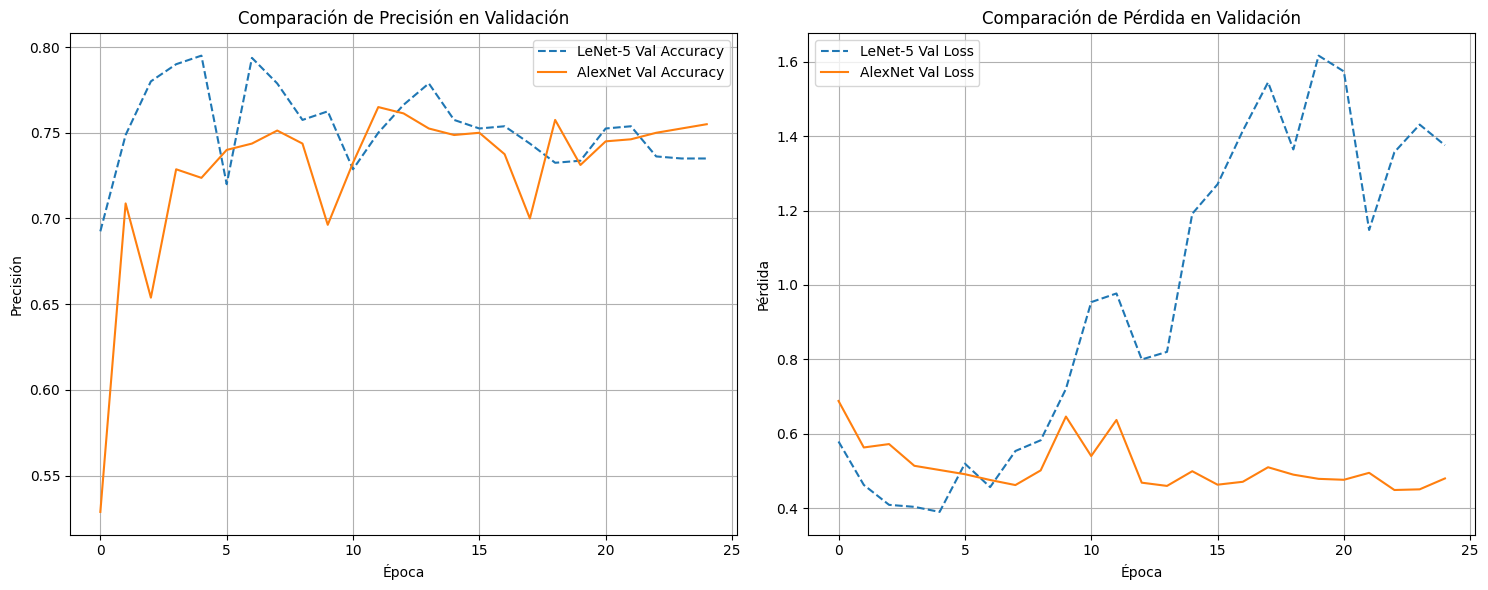

In [20]:
# ── Comparación de modelos —
plt.figure(figsize=(15, 6))

# Gráfico de Precisión
plt.subplot(1, 2, 1)
plt.plot(history_lenet.history['val_accuracy'],
         label='LeNet-5 Val Accuracy', linestyle='--')
plt.plot(history_alexnet.history['val_accuracy'],
         label='AlexNet Val Accuracy', linestyle='-')
plt.title('Comparación de Precisión en Validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

# Gráfico de Pérdida
plt.subplot(1, 2, 2)
plt.plot(history_lenet.history['val_loss'],
         label='LeNet-5 Val Loss', linestyle='--')
plt.plot(history_alexnet.history['val_loss'],
         label='AlexNet Val Loss', linestyle='-')
plt.title('Comparación de Pérdida en Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
# Evaluación final sobre el conjunto de prueba
print("=" * 50)
print("📊 EVALUACIÓN FINAL DE LOS MODELOS")
print("=" * 50)

loss_lenet, acc_lenet = lenet_model.evaluate(x_test, y_test_cat, verbose=0)
loss_alex,  acc_alex  = alexnet_model.evaluate(x_test, y_test_cat, verbose=0)

print(f"\n🔹 LeNet-5")
print(f"   Accuracy en prueba : {acc_lenet*100:.2f}%")
print(f"   Loss en prueba     : {loss_lenet:.4f}")

print(f"\n🔹 AlexNet")
print(f"   Accuracy en prueba : {acc_alex*100:.2f}%")
print(f"   Loss en prueba     : {loss_alex:.4f}")

ganador = "LeNet-5" if acc_lenet > acc_alex else "AlexNet"
print(f"\n🏆 Mejor modelo en este experimento: {ganador}")

📊 EVALUACIÓN FINAL DE LOS MODELOS

🔹 LeNet-5
   Accuracy en prueba : 73.50%
   Loss en prueba     : 1.3757

🔹 AlexNet
   Accuracy en prueba : 75.50%
   Loss en prueba     : 0.4798

🏆 Mejor modelo en este experimento: AlexNet


## 9. Predicciones con Imágenes Nuevas

Probamos los modelos con imágenes del conjunto de prueba — datos
que nunca vieron durante el entrenamiento. Evaluamos con:

- **Visualización de predicciones** individuales con nivel de confianza
- **Matriz de confusión** para entender el tipo de errores
- **Sensibilidad y Especificidad** — métricas críticas en medicina

> En detección de cáncer, los **Falsos Negativos** (cáncer no detectado)
> son el error más peligroso. Por eso la **Sensibilidad** es la métrica
> más importante en este contexto.

In [22]:
# ── Predicción con imágenes del conjunto de prueba ──
# Usamos imágenes de x_test que el modelo nunca vio durante el entrenamiento
def predecir_y_mostrar(modelo, nombre_modelo, x_test, y_test, n=10):
    """
    Toma n imágenes aleatorias del conjunto de prueba,
    predice su clase y las muestra con el resultado.
    Verde = predicción correcta / Rojo = predicción incorrecta
    """
    indices = np.random.choice(len(x_test), n, replace=False)
    etiquetas_texto = {0: 'Sin Cáncer', 1: 'Con Cáncer'}

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    axes = axes.flatten()
    fig.suptitle(f'🔬 Predicciones — {nombre_modelo}', fontsize=14, fontweight='bold')

    for i, idx in enumerate(indices):
        imagen = x_test[idx]
        etiqueta_real = int(y_test[idx])

        # Predecir
        pred = modelo.predict(imagen[np.newaxis, ...], verbose=0)
        clase_pred = int(np.argmax(pred))
        confianza  = float(np.max(pred)) * 100

        # Color según acierto
        color = 'green' if clase_pred == etiqueta_real else 'red'
        icono = '✅' if clase_pred == etiqueta_real else '❌'

        axes[i].imshow(imagen)
        axes[i].axis('off')
        axes[i].set_title(
            f"{icono} Real: {etiquetas_texto[etiqueta_real]}\n"
            f"Pred: {etiquetas_texto[clase_pred]} ({confianza:.1f}%)",
            color=color, fontsize=8, fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

    # Resumen
    preds_todas = modelo.predict(x_test, verbose=0)
    clases_pred = np.argmax(preds_todas, axis=1)
    aciertos = int((clases_pred == y_test).sum())
    print(f"📊 Resumen sobre todo el conjunto de prueba ({len(y_test)} imágenes):")
    print(f"   Correctas  : {aciertos} ({aciertos/len(y_test)*100:.1f}%)")
    print(f"   Incorrectas: {len(y_test)-aciertos} ({(len(y_test)-aciertos)/len(y_test)*100:.1f}%)")

print("✅ Función de predicción definida")

✅ Función de predicción definida



🔹 PREDICCIONES — LeNet-5


/tmp/ipykernel_3667/1486976266.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3667/1486976266.py:37: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3667/1486976266.py:37: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


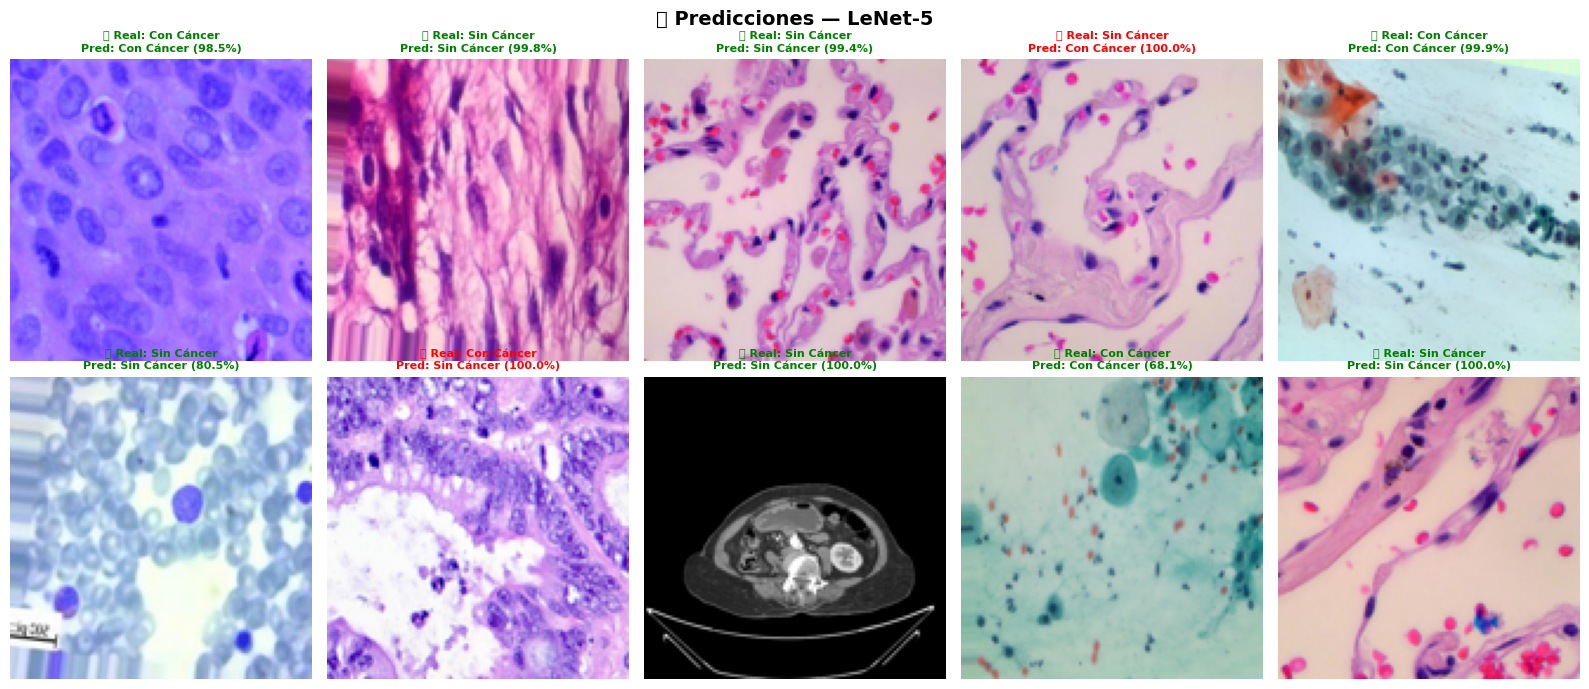

📊 Resumen sobre todo el conjunto de prueba (800 imágenes):
   Correctas  : 588 (73.5%)
   Incorrectas: 212 (26.5%)


In [23]:
print("\n" + "="*50)
print("🔹 PREDICCIONES — LeNet-5")
print("="*50)
predecir_y_mostrar(lenet_model, "LeNet-5", x_test, y_test)


🔹 PREDICCIONES — AlexNet


/tmp/ipykernel_3667/1486976266.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3667/1486976266.py:37: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3667/1486976266.py:37: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


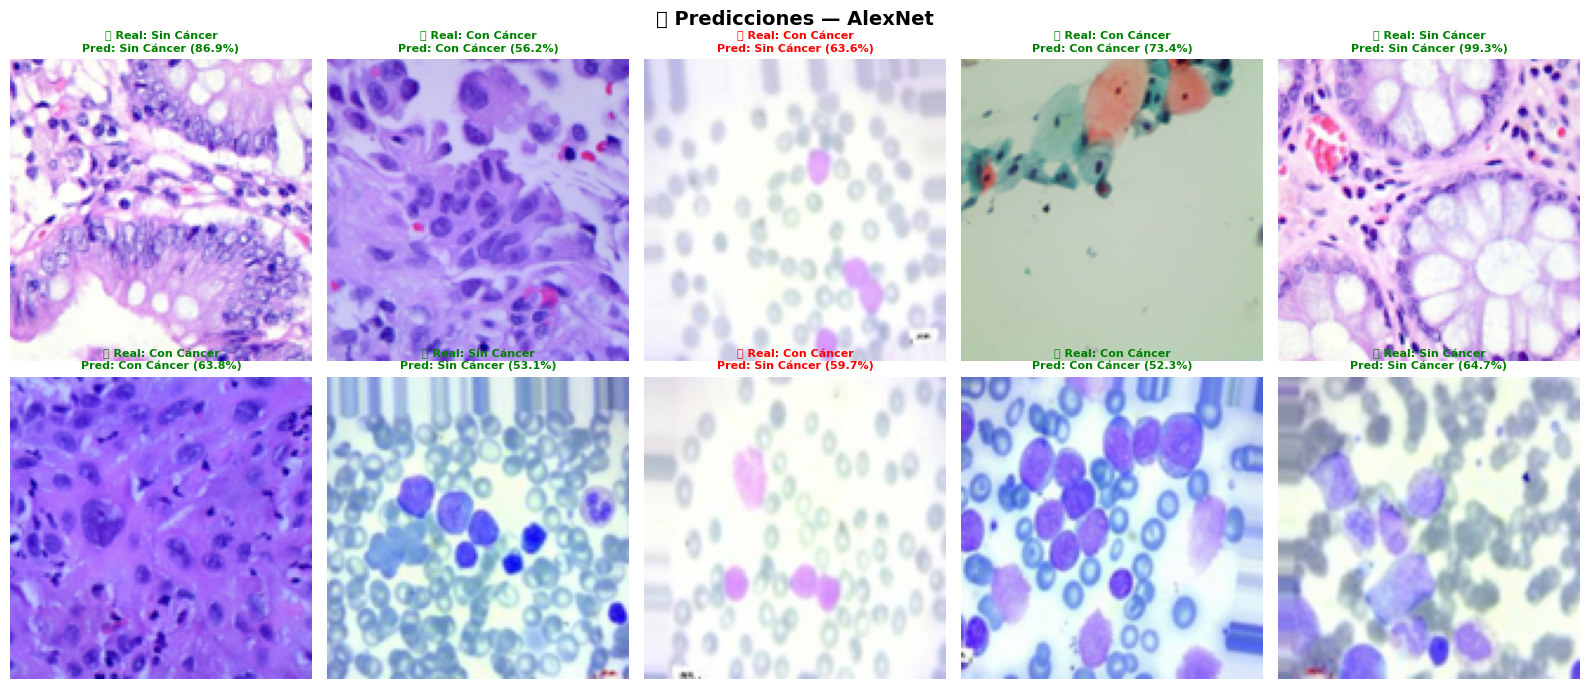

📊 Resumen sobre todo el conjunto de prueba (800 imágenes):
   Correctas  : 604 (75.5%)
   Incorrectas: 196 (24.5%)


In [24]:
print("\n" + "="*50)
print("🔹 PREDICCIONES — AlexNet")
print("="*50)
predecir_y_mostrar(alexnet_model, "AlexNet", x_test, y_test)

In [25]:
# Matriz de confusión — muestra exactamente dónde falla cada modelo
def matriz_confusion(modelo, nombre, x_test, y_test):
    preds = np.argmax(modelo.predict(x_test, verbose=0), axis=1)
    etiquetas = ['Sin Cáncer', 'Con Cáncer']

    # Calcular matriz manualmente
    tp = int(((preds == 1) & (y_test == 1)).sum())  # Cáncer detectado correctamente
    tn = int(((preds == 0) & (y_test == 0)).sum())  # No cáncer correctamente
    fp = int(((preds == 1) & (y_test == 0)).sum())  # Falsa alarma
    fn = int(((preds == 0) & (y_test == 1)).sum())  # Cáncer NO detectado ⚠️

    matriz = np.array([[tn, fp], [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(matriz, cmap='Blues')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: Sin Cáncer', 'Pred: Con Cáncer'])
    ax.set_yticklabels(['Real: Sin Cáncer', 'Real: Con Cáncer'])
    ax.set_title(f'Matriz de Confusión — {nombre}', fontsize=13, fontweight='bold')

    for i in range(2):
        for j in range(2):
            color = 'white' if matriz[i,j] > matriz.max()/2 else 'black'
            ax.text(j, i, str(matriz[i,j]), ha='center', va='center',
                    fontsize=16, color=color, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print(f"\n📋 Métricas clave — {nombre}:")
    print(f"   Verdaderos Positivos (cáncer detectado)    : {tp}")
    print(f"   Verdaderos Negativos (no cáncer correcto)  : {tn}")
    print(f"   Falsos Positivos (alarma innecesaria)      : {fp}")
    print(f"   ⚠️ Falsos Negativos (cáncer NO detectado)  : {fn}")

    sensibilidad = tp / (tp + fn) if (tp + fn) > 0 else 0
    especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"\n   Sensibilidad (detección de cáncer real)    : {sensibilidad*100:.1f}%")
    print(f"   Especificidad (exclusión de no cáncer)     : {especificidad*100:.1f}%")

print("✅ Función de matriz de confusión definida")

✅ Función de matriz de confusión definida


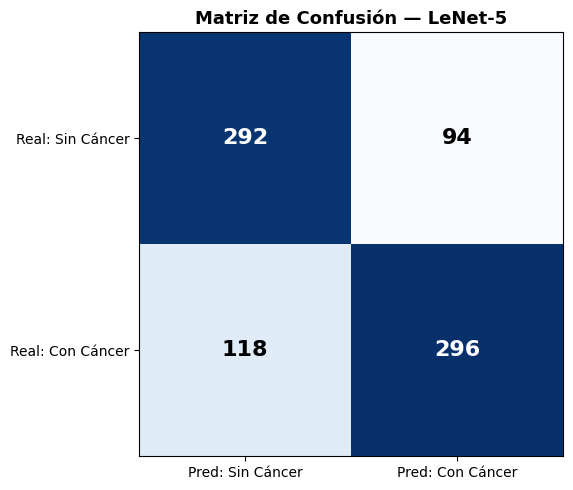


📋 Métricas clave — LeNet-5:
   Verdaderos Positivos (cáncer detectado)    : 296
   Verdaderos Negativos (no cáncer correcto)  : 292
   Falsos Positivos (alarma innecesaria)      : 94
   ⚠️ Falsos Negativos (cáncer NO detectado)  : 118

   Sensibilidad (detección de cáncer real)    : 71.5%
   Especificidad (exclusión de no cáncer)     : 75.6%


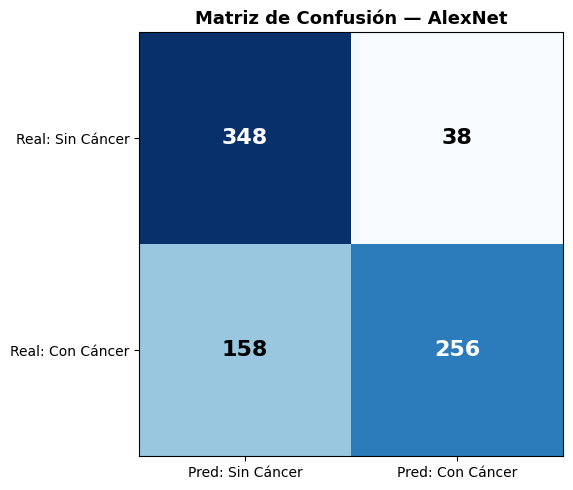


📋 Métricas clave — AlexNet:
   Verdaderos Positivos (cáncer detectado)    : 256
   Verdaderos Negativos (no cáncer correcto)  : 348
   Falsos Positivos (alarma innecesaria)      : 38
   ⚠️ Falsos Negativos (cáncer NO detectado)  : 158

   Sensibilidad (detección de cáncer real)    : 61.8%
   Especificidad (exclusión de no cáncer)     : 90.2%


In [26]:
matriz_confusion(lenet_model,  "LeNet-5", x_test, y_test)
matriz_confusion(alexnet_model, "AlexNet", x_test, y_test)

## Análisis de Resultados

### Resultados de Entrenamiento

| Modelo  | Train Accuracy | Val Accuracy | Val Loss |
|---------|---------------|--------------|----------|
| LeNet-5 | 99.31%        | 73.50%       | 1.3757   |
| AlexNet | 79.44%        | 75.50%       | 0.4798   |

LeNet-5 mostró sobreajuste severo: accuracy de entrenamiento del 99%
frente a solo 73.5% en validación, con pérdida de validación que se
disparó hasta 1.62 en la época 20. AlexNet mostró un entrenamiento
notablemente más estable: train y val accuracy se mantuvieron cercanos
(79.44% vs 75.50%), y la pérdida de validación se estabilizó
alrededor de 0.47-0.50 desde la época 6. El Dropout (0.5) cumplió
su función como regularizador efectivo.

### Evaluación Final sobre Conjunto de Prueba (800 imágenes)

| Métrica          | LeNet-5   | AlexNet   |
|------------------|-----------|-----------|
| Accuracy         | 73.50%    | 75.50% 🏆 |
| Sensibilidad     | 71.5%  🏆 | 61.8%     |
| Especificidad    | 75.6%     | 90.2%  🏆 |
| Falsos Negativos | 118    🏆 | 158       |
| Falsos Positivos | 94        | 38     🏆 |

### Impacto de aumentar los datos de entrenamiento

Inicialmente se trabajó con el parámetro MUESTRAS = 1000 (MUESTRAS=1000 por clase), Comparando con el experimento anterior:

| Modelo  | Val Acc anterior | Val Acc nuevo | Mejora |
|---------|-----------------|---------------|--------|
| LeNet-5 | 70.25%          | 73.50%        | +3.25% |
| AlexNet | 72.25%          | 75.50%        | +3.25% |

Duplicar los datos produjo una mejora consistente de ~3% en ambos
modelos, confirmando que más datos beneficia el aprendizaje dentro
de los límites de cada arquitectura.

### Hallazgo destacado

Con más datos los roles se invirtieron respecto al experimento
anterior: LeNet-5 ahora supera a AlexNet en Sensibilidad (71.5%
vs 61.8%) y tiene menos Falsos Negativos (118 vs 158), mientras
que AlexNet lidera en Especificidad (90.2% vs 75.6%) y menos
Falsos Positivos (38 vs 94). Esto demuestra que más datos no
mejora todas las métricas uniformemente y que la elección del
modelo óptimo depende del objetivo clínico.

### Conclusión

No hay un ganador absoluto — depende de la prioridad clínica:

- **Si se prioriza no perder ningún cáncer** → **LeNet-5**
  (Sensibilidad 71.5%, solo 118 Falsos Negativos)
- **Si se prioriza evitar falsas alarmas** → **AlexNet**
  (Especificidad 90.2%, solo 38 Falsos Positivos)
- **Si se prioriza accuracy general** → **AlexNet** (75.5%)

En medicina, la Sensibilidad suele ser la métrica crítica — es
preferible una alarma innecesaria que dejar un cáncer sin detectar.
Bajo este criterio, **LeNet-5 es el modelo recomendado** en este
experimento con MUESTRAS=2000.